In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from Files import Model
from Files import Tools
from Files import NEGM
from Files import HelperFunctions
from Files import Estimation

In [2]:
model = Model.DurableBufferStock()
model.modelSetup()
model.createGrids()
model.solve()
model.simulate()

par = model.par
sol = model.sol
sim = model.sim

Number of gridpoints: t = 50 p = 20 n = 40 m = 40
48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
1
0
Solver time: 2114.16 seconds
Simulation time: 830.33 seconds


In [3]:
np.max(sol.a)

9.804867177768449

In [4]:
np.mean(sol.c)

1.3564052956877592

In [5]:
np.mean(sol.d)

1.027592154960228

In [6]:
print(np.isnan(sol.c).sum())

0


In [8]:
for t in range(par.T):
    print(
        t,
        f"c: {np.nanmin(sim.c[t,:]):.2f} {np.nanmax(sim.c[t,:]):.2f}",
        f"d: {np.nanmin(sim.d[t,:]):.2f} {np.nanmax(sim.d[t,:]):.2f}",
        f"p: {np.nanmin(sim.p[t,:]):.2f} {np.nanmax(sim.p[t,:]):.2f}",
        f"n: {np.nanmin(sim.n[t,:]):.2f} {np.nanmax(sim.n[t,:]):.2f}",
        f"m: {np.nanmin(sim.m[t,:]):.2f} {np.nanmax(sim.m[t,:]):.2f}"
    )

0 c: 0.24 1.86 d: 0.06 1.67 p: 0.35 2.56 n: 0.26 1.67 m: 0.53 3.10
1 c: 0.23 1.92 d: 0.05 2.14 p: 0.35 2.92 n: 0.05 1.42 m: 0.87 4.61
2 c: 0.20 2.00 d: 0.06 2.24 p: 0.30 3.48 n: 0.05 1.82 m: 0.99 4.82
3 c: 0.21 2.04 d: 0.05 2.48 p: 0.29 3.46 n: 0.05 1.91 m: 1.07 6.00
4 c: 0.20 2.07 d: 0.05 2.57 p: 0.27 3.77 n: 0.05 2.11 m: 1.28 6.62
5 c: 0.18 2.09 d: 0.05 3.00 p: 0.24 4.30 n: 0.05 2.18 m: 1.31 7.71
6 c: 0.18 2.11 d: 0.05 3.00 p: 0.24 5.69 n: 0.05 2.55 m: 1.47 10.93
7 c: 0.19 2.13 d: 0.05 3.00 p: 0.23 5.66 n: 0.05 2.55 m: 1.59 13.47
8 c: 0.18 2.15 d: 0.05 3.00 p: 0.20 6.45 n: 0.05 2.55 m: 1.70 14.80
9 c: 0.16 2.17 d: 0.05 3.00 p: 0.17 5.60 n: 0.04 2.55 m: 1.72 13.82
10 c: 0.15 2.19 d: 0.05 3.00 p: 0.15 6.38 n: 0.05 2.55 m: 1.82 12.96
11 c: 0.15 2.22 d: 0.05 3.00 p: 0.15 6.35 n: 0.05 2.55 m: 1.94 13.71
12 c: 0.16 2.23 d: 0.05 3.00 p: 0.15 6.32 n: 0.05 2.55 m: 2.06 13.66
13 c: 0.16 2.26 d: 0.05 3.00 p: 0.15 5.49 n: 0.05 2.55 m: 2.09 13.92
14 c: 0.17 2.28 d: 0.05 3.00 p: 0.15 5.46 n: 0.05 

In [9]:
print(f"{np.nanmin(par.sim_p_ini):.2f} {np.nanmax(par.sim_p_ini):.2f} {np.mean(par.sim_p_ini):.2f}")
print(f"{np.nanmin(par.sim_d_ini):.2f} {np.nanmax(par.sim_d_ini):.2f} {np.mean(par.sim_d_ini):.2f}")
print(f"{np.nanmin(par.sim_a_ini):.2f} {np.nanmax(par.sim_a_ini):.2f} {np.mean(par.sim_a_ini):.2f}")

0.44 2.45 1.02
0.31 1.97 0.82
0.13 0.32 0.20


In [10]:
for t in range(par.T):

    p_max = par.grid_p[t,-1]
    n_max = par.grid_n[t,-1]
    m_max = par.grid_m[t,-1]

    print(
        t,
        f"p max: {np.nanmax(sim.p[t,:]):.2f}",
        f"at upper bound: {np.sum(sim.p[t,:] >= p_max):,}",

        f"n max: {np.nanmax(sim.n[t,:]):.2f}",
        f"at upper bound: {np.sum(sim.n[t,:] >= n_max):,}",

        f"m max: {np.nanmax(sim.m[t,:]):.2f}",
        f"at upper bound: {np.sum(sim.m[t,:] >= m_max):,}"
    )

0 p max: 2.56 at upper bound: 0 n max: 1.67 at upper bound: 0 m max: 3.10 at upper bound: 0
1 p max: 2.92 at upper bound: 0 n max: 1.42 at upper bound: 0 m max: 4.61 at upper bound: 0
2 p max: 3.48 at upper bound: 1 n max: 1.82 at upper bound: 0 m max: 4.82 at upper bound: 0
3 p max: 3.46 at upper bound: 8 n max: 1.91 at upper bound: 0 m max: 6.00 at upper bound: 0
4 p max: 3.77 at upper bound: 18 n max: 2.11 at upper bound: 0 m max: 6.62 at upper bound: 0
5 p max: 4.30 at upper bound: 25 n max: 2.18 at upper bound: 0 m max: 7.71 at upper bound: 0
6 p max: 5.69 at upper bound: 41 n max: 2.55 at upper bound: 0 m max: 10.93 at upper bound: 1
7 p max: 5.66 at upper bound: 58 n max: 2.55 at upper bound: 0 m max: 13.47 at upper bound: 1
8 p max: 6.45 at upper bound: 93 n max: 2.55 at upper bound: 0 m max: 14.80 at upper bound: 2
9 p max: 5.60 at upper bound: 125 n max: 2.55 at upper bound: 0 m max: 13.82 at upper bound: 6
10 p max: 6.38 at upper bound: 170 n max: 2.55 at upper bound: 0 m ma

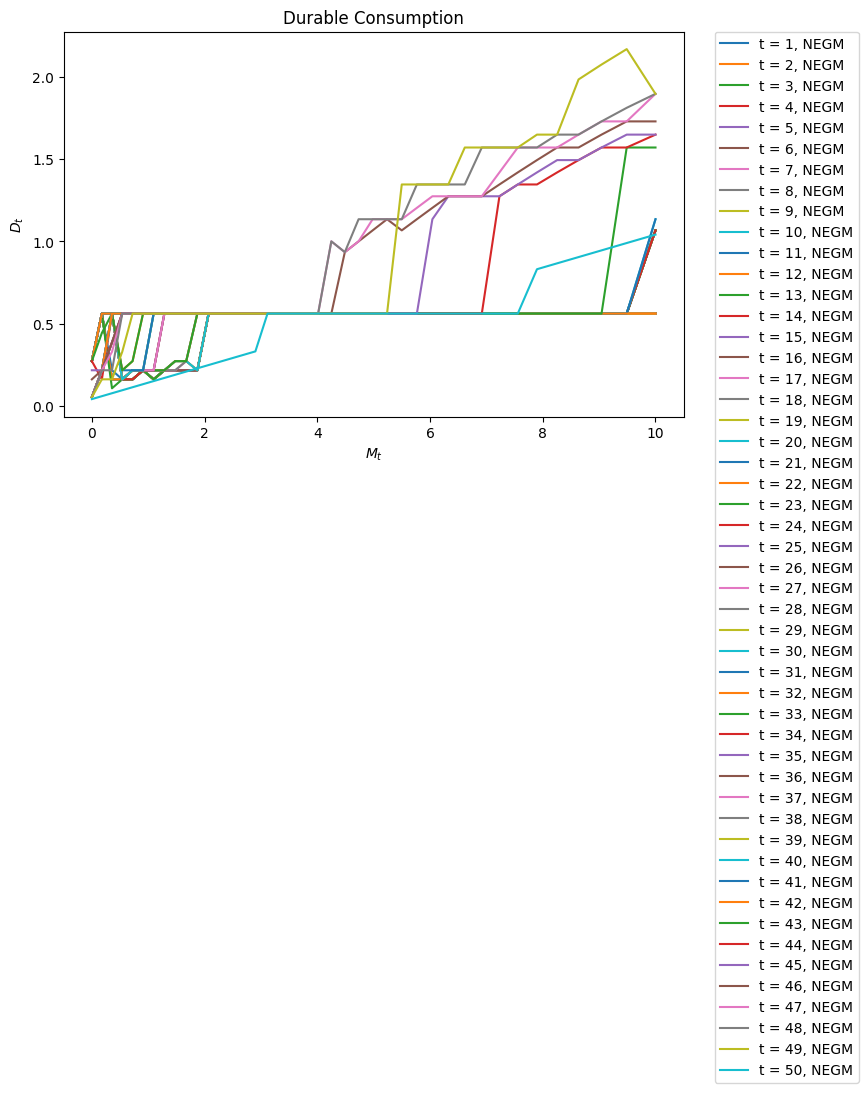

In [11]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):

    ax.plot(sol.m[t, 5, 10, :],sol.d[t, 5, 10, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$D_t$")
ax.set_title(f'Durable Consumption')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

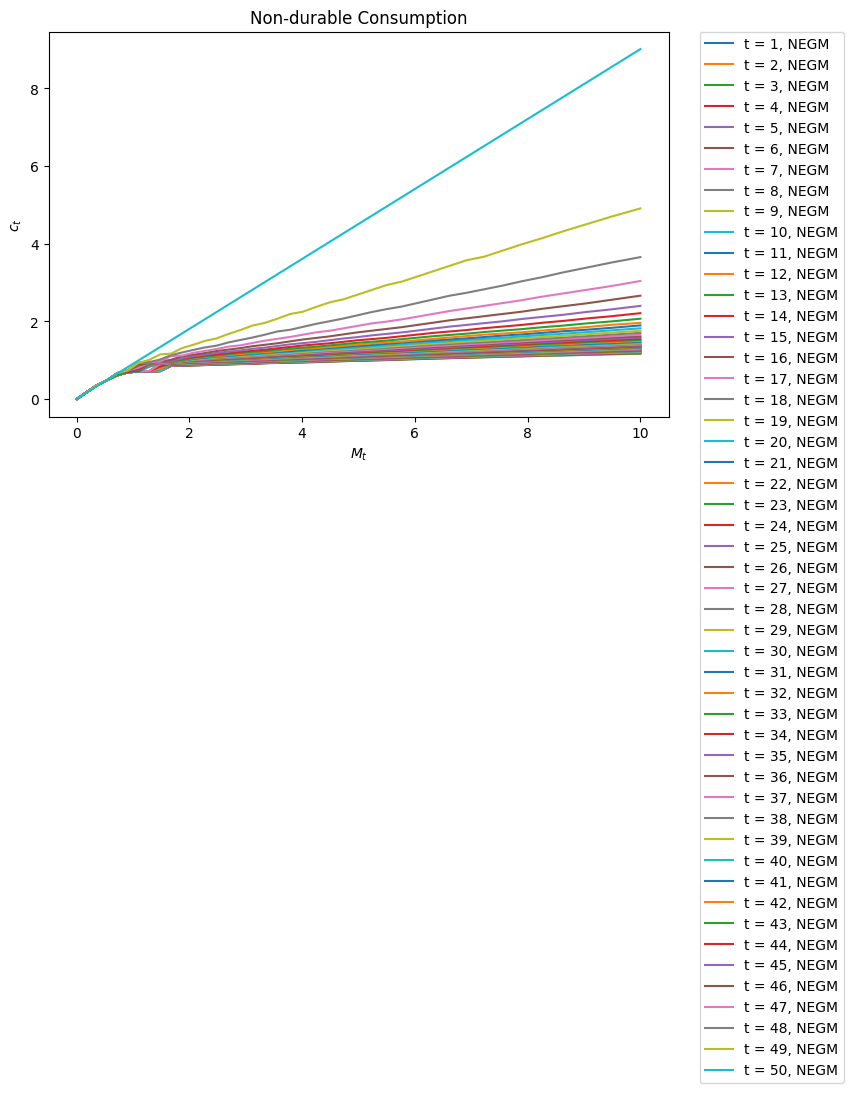

In [12]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):
    ax.plot(sol.m[t, 9, 0, :],sol.c[t, 9, 0, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$c_t$")
ax.set_title(f'Non-durable Consumption')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

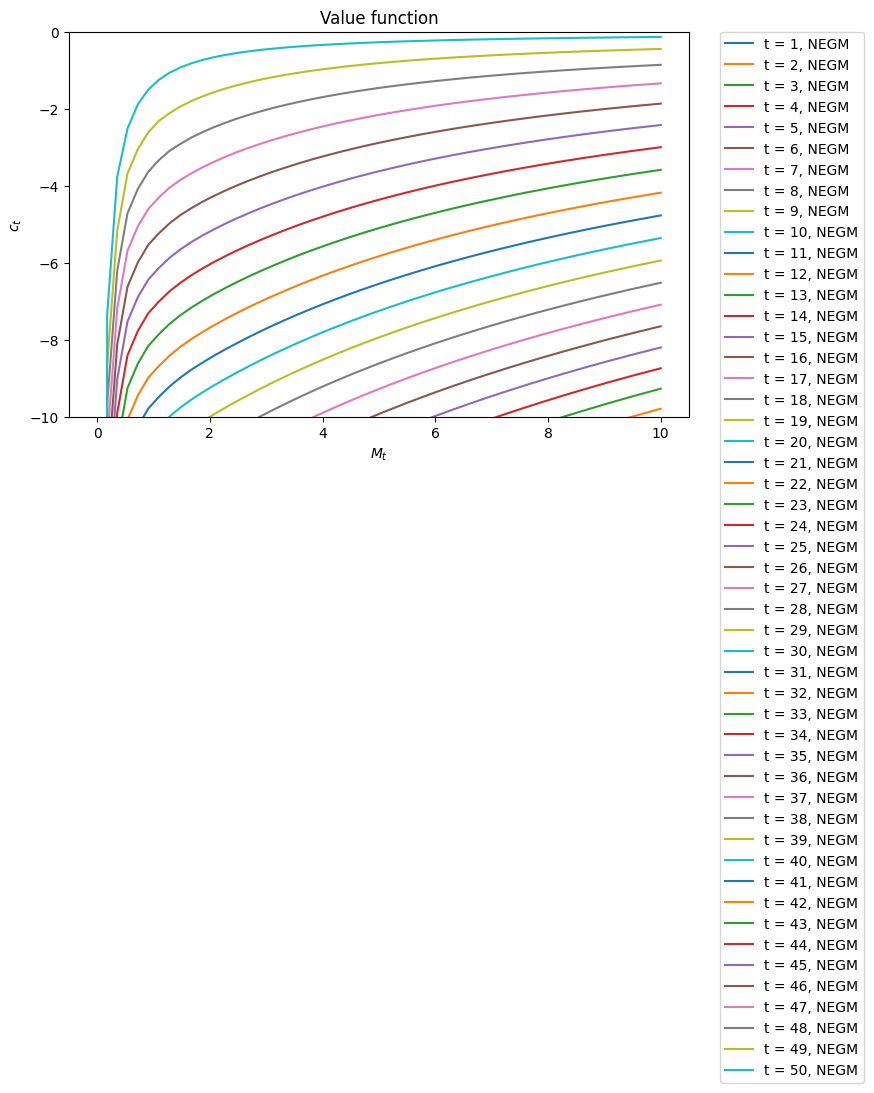

In [13]:
fig = plt.figure(figsize=(8,5))# figsize is in inches...
ax = fig.add_subplot(1,1,1)
for t in range(par.T):
    ax.plot(sol.m[t, 9, 0, :],sol.v[t, 9, 0, :],  label=f"t = {t + 1}, NEGM",  linestyle='-')

ax.set_xlabel(f"$M_t$")
ax.set_ylabel(f"$c_t$")
ax.set_title(f'Value function')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.set_ylim(bottom=-10,top=0)
plt.show()

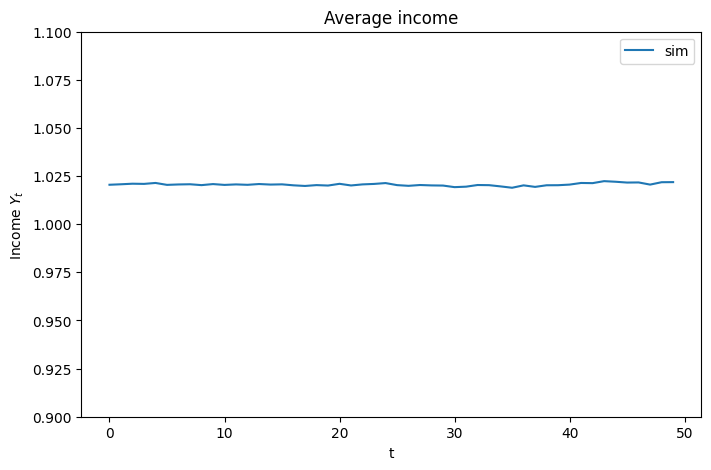

In [14]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.y, axis=1), label='sim')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Income $Y_t$")
ax.set_title(f'Average income')
ax.legend()
ax.set_ylim(bottom=0.9,top=1.1)
plt.show()

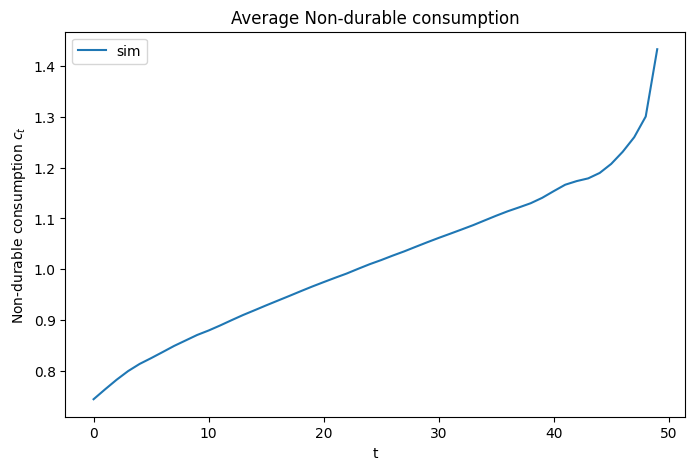

0.7450292883478757
0.7644551765050599


In [15]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.c, axis=1), label='sim')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Non-durable consumption $c_t$")
ax.set_title(f'Average Non-durable consumption')
ax.legend()
#ax.set_ylim(bottom=0.5,top=1.5)
plt.show()

print(np.mean(sim.c[0]))
print(np.mean(sim.c[1]))

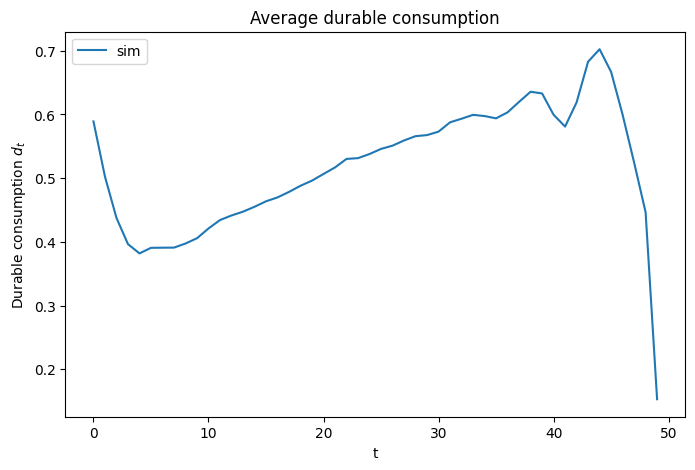

In [16]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)
ax.plot(np.arange(par.T), np.mean(sim.d, axis=1), label='sim')
ax.set_xlabel(f"t")
ax.set_ylabel(f"Durable consumption $d_t$")
ax.set_title(f'Average durable consumption')
ax.legend()
plt.show()

In [17]:
np.mean(sim.c)

1.0165494218755802

In [18]:
np.mean(sim.c)-0.979

0.03754942187558019

In [19]:
np.var(sim.c)

0.30498653286680527

In [20]:
np.var(sim.c) - 0.256

0.048986532866805266

In [21]:
np.mean(sim.d)

0.5180382038714985

In [22]:
np.mean(sim.d) - 0.562

-0.043961796128501596

In [23]:
np.var(sim.d)

0.15218810430625057

In [24]:
np.var(sim.d) - 0.112

0.04018810430625057

In [25]:
np.mean(sim.v)

-22.946258813839314

In [26]:
np.mean(sim.v) + 32.213

9.266741186160687

In [27]:
np.mean(sim.v[0])

-38.05535497953368